In [1]:
import os, json
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats
import seaborn as sns
import semopy
import graphviz

In [2]:
datadir = os.path.join("data")
data = os.path.join(datadir, "caduceus_accurate_data.csv")

df = pd.read_csv(data)
initial_count = len(df)

# 1. Robust Age Extraction
# Convert everything to a string, then extract only the first sequence of digits 
# (e.g., "18 Tuổi" becomes "18", "Năm 2004" becomes "2004")
df['Tuổi'] = df['Tuổi'].astype(str).str.extract(r'(\d+)')[0].astype(float)

# 2. Correct Birth Years to Current Age
# If the extracted number is > 100, we assume it's a birth year. Subtract from 2026.
df['Tuổi'] = df['Tuổi'].apply(lambda x: 2026 - x if pd.notnull(x) and x > 100 else x)

# 3. Filter for Target Demographic (Age >= 18)
df = df[df['Tuổi'] >= 18].copy()
final_count = len(df)

print(f"Initial row count: {initial_count}")
print(f"Rows after robust string extraction and filtering: {final_count}")
print(f"Removed {initial_count - final_count} participant(s).")

print(f"\nNew Age Summary:")
print(df['Tuổi'].describe())

Initial row count: 515
Rows after robust string extraction and filtering: 406
Removed 109 participant(s).

New Age Summary:
count    406.000000
mean      23.174877
std        3.819567
min       18.000000
25%       20.000000
50%       23.000000
75%       25.000000
max       46.000000
Name: Tuổi, dtype: float64


In [3]:

# 1. Rename columns for easier manipulation
new_cols = ['Timestamp', 'Gender', 'Age', 'Location', 'Education', 'Access_Info', 'Heard_App', 'Use_App']
new_cols += [f'ATSPPH_{i}' for i in range(1, 11)]
new_cols += [f'Trust_{i}' for i in range(1, 13)]
new_cols += [f'Interest_{i}' for i in range(1, 21)]
new_cols += [f'Feature_{i}' for i in range(1, 16)]
df.columns = new_cols

# 1. Define the translation dictionaries
gender_map = {
    'Nam': 'Male',
    'Nữ': 'Female'
}

location_map = {
    'Thành thị': 'Urban',
    'Nông thôn': 'Rural'
}

# Grouping the 4 original education tiers into your 2 requested tiers
education_map = {
    'Sau Đại học': 'College or higher',       # Post-graduate
    'Cao Đẳng/ Đại học': 'College or higher', # College/University
    'Trung học phổ thông': 'High school or lower', # High School
    'Trung học cơ sở': 'High school or lower'      # Middle School
}

yes_no_map = {
    'Có': 'Yes',
    'Không': 'No'
}

# 2. Apply the mappings to the dataframe
df['Gender'] = df['Gender'].map(gender_map)
df['Location'] = df['Location'].map(location_map)
df['Education'] = df['Education'].map(education_map)

# Apply the Yes/No mapping to the remaining three columns
df['Access_Info'] = df['Access_Info'].map(yes_no_map)
df['Heard_App'] = df['Heard_App'].map(yes_no_map)
df['Use_App'] = df['Use_App'].map(yes_no_map)

# 2. Define Mappings for the Likert scales
likert_mapping = {
    'Hoàn toàn không đồng ý': 1, 'Không đồng ý': 2, 'Trung lập': 3, 
    'Đồng ý': 4, 'Hoàn toàn đồng ý': 5
}

interest_mapping = {
    'Hoàn toàn không quan tâm': 1, 'Có hứng thú một chút': 2, 
    'Quan tâm ở mức trung bình': 3, 'Khá quan tâm': 4, 'Rất quan tâm': 5
}

feature_mapping = {
    'Hoàn toàn không liên quan': 1, 'Không liên quan': 2, 
    'Hơi liên quan': 3, 'Khá liên quan': 4, 'Rất liên quan': 5
}

# 3. Apply mappings to the respective columns
for i in range(1, 11):
    df[f'ATSPPH_{i}'] = df[f'ATSPPH_{i}'].map(likert_mapping)

for i in range(1, 13):
    df[f'Trust_{i}'] = df[f'Trust_{i}'].map(likert_mapping)
    
for i in range(1, 21):
    df[f'Interest_{i}'] = df[f'Interest_{i}'].map(interest_mapping)

for i in range(1, 16):
    df[f'Feature_{i}'] = df[f'Feature_{i}'].map(feature_mapping)

# Save the cleaned dataset
df.to_csv("cleaned_mental_health_survey.csv", index=False)

In [4]:
import pandas as pd

# Load the finalized dataset
df = pd.read_csv("caduceus_data_cleaned.csv")
total_n = len(df)

print(f"Total Participants (N) = {total_n}\n")
print(f"{'Variable':<45} | {'n':<5} | {'%'}")
print("-" * 60)

# Define a helper function to calculate and print the stats
def print_demographic(category_name, column_name, values):
    print(f"{category_name}")
    for val in values:
        # Count how many rows match the specific value
        count = len(df[df[column_name] == val])
        # Calculate the percentage
        pct = (count / total_n) * 100
        # Print with clean formatting
        print(f"    {val:<41} | {count:<5} | {pct:.1f}%")

# Generate the stats for each category
print_demographic("Gender", "Gender", ["Male", "Female"])
print_demographic("Residence", "Location", ["Urban", "Rural"])
print_demographic("Level of Education", "Education", ["College or higher", "High school or lower"])
print_demographic("Accessing Mental Healthcare Information", "Access_Info", ["Yes", "No"])
print_demographic("Have you ever heard about Mental Health apps?", "Heard_App", ["Yes", "No"])
print_demographic("Current Mental Health apps use", "Use_App", ["Yes", "No"])

Total Participants (N) = 406

Variable                                      | n     | %
------------------------------------------------------------
Gender
    Male                                      | 166   | 40.9%
    Female                                    | 240   | 59.1%
Residence
    Urban                                     | 224   | 55.2%
    Rural                                     | 182   | 44.8%
Level of Education
    College or higher                         | 310   | 76.4%
    High school or lower                      | 96    | 23.6%
Accessing Mental Healthcare Information
    Yes                                       | 335   | 82.5%
    No                                        | 71    | 17.5%
Have you ever heard about Mental Health apps?
    Yes                                       | 262   | 64.5%
    No                                        | 144   | 35.5%
Current Mental Health apps use
    Yes                                       | 126   | 31.0%
    No          

In [15]:
import pandas as pd

# Load the finalized dataset
df = pd.read_csv("caduceus_data_cleaned.csv")

# 1. Reverse code the specific items (5-point scale: new = 6 - old)
reverse_items = ['ATSPPH_2', 'ATSPPH_4', 'ATSPPH_8', 'ATSPPH_9', 'ATSPPH_10']
for item in reverse_items:
    df[item] = 6 - df[item]

# 2. Define the columns for the ATSPPH scale
atspph_items = [f'ATSPPH_{i}' for i in range(1, 11)]

# 3. Calculate Total Sum score per participant
df['ATSPPH_Total'] = df[atspph_items].sum(axis=1)

print(f"{'Item':<10} | {'Mean':<5} | {'SD':<4} | {'Min'} | {'Max'}")
print("-" * 45)

# 4. Calculate and print stats for each individual item
for item in atspph_items:
    mean_val = df[item].mean()
    sd_val = df[item].std()
    min_val = df[item].min()
    max_val = df[item].max()
    print(f"{item:<10} | {mean_val:.2f} | {sd_val:.2f} | {min_val}   | {max_val}")

print("-" * 45)

# 5. Calculate and print stats for the Total Score
total_mean = df['ATSPPH_Total'].mean()
total_sd = df['ATSPPH_Total'].std()
total_min = df['ATSPPH_Total'].min()
total_max = df['ATSPPH_Total'].max()
print(f"Total      | {total_mean:.2f} | {total_sd:.2f} | {total_min}  | {total_max}")

Item       | Mean  | SD   | Min | Max
---------------------------------------------
ATSPPH_1   | 3.72 | 1.11 | 1   | 5
ATSPPH_2   | 2.63 | 1.20 | 1   | 5
ATSPPH_3   | 3.84 | 0.96 | 1   | 5
ATSPPH_4   | 2.00 | 0.93 | 1   | 5
ATSPPH_5   | 3.87 | 0.97 | 1   | 5
ATSPPH_6   | 3.79 | 1.01 | 1   | 5
ATSPPH_7   | 3.79 | 1.01 | 1   | 5
ATSPPH_8   | 2.66 | 1.14 | 1   | 5
ATSPPH_9   | 2.42 | 1.04 | 1   | 5
ATSPPH_10  | 2.30 | 0.97 | 1   | 5
---------------------------------------------
Total      | 31.03 | 3.66 | 11  | 45


In [13]:
# 2. Define the columns for the ATSPPH scale
hcts_items = [f'Trust_{i}' for i in range(1, 13)]

# 3. Calculate Total Sum score per participant
df['HCTS_total'] = df[hcts_items].sum(axis=1)

print(f"{'Item':<10} | {'Mean':<5} | {'SD':<4} | {'Min'} | {'Max'}")
print("-" * 45)

# 4. Calculate and print stats for each individual item
for item in hcts_items:
    mean_val = df[item].mean()
    sd_val = df[item].std()
    min_val = df[item].min()
    max_val = df[item].max()
    print(f"{item:<10} | {mean_val:.2f} | {sd_val:.2f} | {min_val}   | {max_val}")

print("-" * 45)

# 5. Calculate and print stats for the Total Score
total_mean = df['HCTS_total'].mean()
total_sd = df['HCTS_total'].std()
total_min = df['HCTS_total'].min()
total_max = df['HCTS_total'].max()
print(f"Total      | {total_mean:.2f} | {total_sd:.2f} | {total_min}  | {total_max}")

Item       | Mean  | SD   | Min | Max
---------------------------------------------
Trust_1    | 3.43 | 1.11 | 1   | 5
Trust_2    | 3.76 | 0.86 | 1   | 5
Trust_3    | 3.77 | 0.88 | 1   | 5
Trust_4    | 3.66 | 0.95 | 1   | 5
Trust_5    | 3.75 | 0.91 | 1   | 5
Trust_6    | 3.76 | 0.93 | 1   | 5
Trust_7    | 3.70 | 0.97 | 1   | 5
Trust_8    | 3.75 | 0.91 | 1   | 5
Trust_9    | 3.71 | 0.97 | 1   | 5
Trust_10   | 3.52 | 1.09 | 1   | 5
Trust_11   | 3.59 | 1.02 | 1   | 5
Trust_12   | 3.65 | 1.02 | 1   | 5
---------------------------------------------
Total      | 44.04 | 9.33 | 12  | 60


In [16]:
# 2. Define the columns for the ATSPPH scale
iidmh_items = [f'Interest_{i}' for i in range(1, 21)]

# 3. Calculate Total Sum score per participant
df['IIDMH_total'] = df[iidmh_items].sum(axis=1)

print(f"{'Item':<10} | {'Mean':<5} | {'SD':<4} | {'Min'} | {'Max'}")
print("-" * 45)

# 4. Calculate and print stats for each individual item
for item in iidmh_items:
    mean_val = df[item].mean()
    sd_val = df[item].std()
    min_val = df[item].min()
    max_val = df[item].max()
    print(f"{item:<10} | {mean_val:.2f} | {sd_val:.2f} | {min_val}   | {max_val}")

print("-" * 45)

# 5. Calculate and print stats for the Total Score
total_mean = df['IIDMH_total'].mean()
total_sd = df['IIDMH_total'].std()
total_min = df['IIDMH_total'].min()
total_max = df['IIDMH_total'].max()
print(f"Total      | {total_mean:.2f} | {total_sd:.2f} | {total_min}  | {total_max}")

Item       | Mean  | SD   | Min | Max
---------------------------------------------
Interest_1 | 3.57 | 1.14 | 1   | 5
Interest_2 | 3.52 | 1.04 | 1   | 5
Interest_3 | 3.58 | 1.10 | 1   | 5
Interest_4 | 3.52 | 1.12 | 1   | 5
Interest_5 | 3.47 | 1.11 | 1   | 5
Interest_6 | 3.48 | 1.12 | 1   | 5
Interest_7 | 3.63 | 1.13 | 1   | 5
Interest_8 | 3.60 | 1.08 | 1   | 5
Interest_9 | 3.60 | 1.11 | 1   | 5
Interest_10 | 3.58 | 1.12 | 1   | 5
Interest_11 | 3.70 | 1.03 | 1   | 5
Interest_12 | 3.60 | 1.03 | 1   | 5
Interest_13 | 3.45 | 1.20 | 1   | 5
Interest_14 | 3.48 | 1.09 | 1   | 5
Interest_15 | 3.52 | 1.13 | 1   | 5
Interest_16 | 3.47 | 1.15 | 1   | 5
Interest_17 | 3.49 | 1.17 | 1   | 5
Interest_18 | 3.45 | 1.18 | 1   | 5
Interest_19 | 3.50 | 1.14 | 1   | 5
Interest_20 | 3.57 | 1.06 | 1   | 5
---------------------------------------------
Total      | 70.76 | 19.46 | 20  | 100


In [17]:
import pandas as pd

# Load the finalized dataset
df = pd.read_csv("caduceus_data_cleaned.csv")

# Create a copy to test the ATSPPH-SF without reverse coding
df_unreversed = df.copy()

# 1. Reverse code the specific ATSPPH items
reverse_items = ['ATSPPH_2', 'ATSPPH_4', 'ATSPPH_8', 'ATSPPH_9', 'ATSPPH_10']
for item in reverse_items:
    df[item] = 6 - df[item]

# 2. Define the columns for each scale
atspph_items = [f'ATSPPH_{i}' for i in range(1, 11)]
trust_items = [f'Trust_{i}' for i in range(1, 13)]
interest_items = [f'Interest_{i}' for i in range(1, 21)]

# 3. Define the Cronbach's Alpha mathematical function
def cronbach_alpha(df_items):
    k = df_items.shape[1]
    var_items = df_items.var(ddof=1)
    var_total = df_items.sum(axis=1).var(ddof=1)
    if var_total == 0: return 0
    return (k / (k - 1)) * (1 - var_items.sum() / var_total)

# 4. Calculate and print the Alphas
print(f"Trust in AI Alpha: {cronbach_alpha(df[trust_items]):.3f}")
print(f"Interest in Apps Alpha: {cronbach_alpha(df[interest_items]):.3f}")
print(f"ATSPPH-SF Alpha (WITH standard reverse coding): {cronbach_alpha(df[atspph_items]):.3f}")
print(f"ATSPPH-SF Alpha (WITHOUT reverse coding): {cronbach_alpha(df_unreversed[atspph_items]):.3f}")

Trust in AI Alpha: 0.949
Interest in Apps Alpha: 0.984
ATSPPH-SF Alpha (WITH standard reverse coding): 0.221
ATSPPH-SF Alpha (WITHOUT reverse coding): 0.899


In [22]:
import pingouin as pg
print(pg.cronbach_alpha(data=df[hcts_items]))
print(pg.cronbach_alpha(data=df[iidmh_items]))
print(pg.cronbach_alpha(data=df[atspph_items]))
print(pg.cronbach_alpha(data=df_unreversed[atspph_items]))

(np.float64(0.9487800230141359), array([0.941, 0.956]))
(np.float64(0.983801532988684), array([0.981, 0.986]))
(np.float64(0.22112918478002083), array([0.103, 0.329]))
(np.float64(0.8985961779703199), array([0.883, 0.913]))


Correlation Matrix:
                 ATSPPH_Score  Trust_Score  Interest_Score
ATSPPH_Score        1.000000     0.797976        0.674877
Trust_Score         0.797976     1.000000        0.702468
Interest_Score      0.674877     0.702468        1.000000


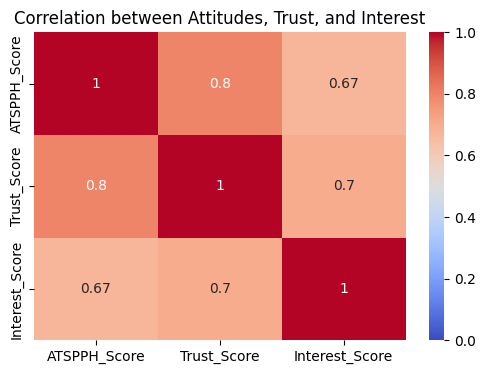

Gender T-Test -> t: nan, p-value: nan


C:\Users\Admin\AppData\Local\Temp\ipykernel_22636\3874210542.py:27: SmallSampleWarning: One or more sample arguments is too small; all returned values will be NaN. See documentation for sample size requirements.
  t_stat, p_val = stats.ttest_ind(female_interest, male_interest)


In [6]:
# Load the CLEANED data from Step 1 (Do NOT reverse code)
df = pd.read_csv("cleaned_mental_health_survey.csv")

# 1. Calculate the final mean scores for each participant
atspph_items = [f'ATSPPH_{i}' for i in range(1, 11)]
trust_items = [f'Trust_{i}' for i in range(1, 13)]
interest_items = [f'Interest_{i}' for i in range(1, 21)]

df['ATSPPH_Score'] = df[atspph_items].mean(axis=1)
df['Trust_Score'] = df[trust_items].mean(axis=1)
df['Interest_Score'] = df[interest_items].mean(axis=1)

# 2. Correlation Matrix
corr_matrix = df[['ATSPPH_Score', 'Trust_Score', 'Interest_Score']].corr()
print("Correlation Matrix:\n", corr_matrix)

# 3. Visualization: Correlation Heatmap
plt.figure(figsize=(6, 4))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', vmin=0, vmax=1)
plt.title('Correlation between Attitudes, Trust, and Interest')
plt.show()

# 4. T-Test: Interest by Gender
female_interest = df[df['Gender'] == 'Nữ']['Interest_Score']
male_interest = df[df['Gender'] == 'Nam']['Interest_Score']

t_stat, p_val = stats.ttest_ind(female_interest, male_interest)
print(f"Gender T-Test -> t: {t_stat:.3f}, p-value: {p_val:.3f}")

In [7]:
from scipy import stats

print("=== DEMOGRAPHIC T-TESTS ===")

# ---------------------------------------------------------
# 1. T-Test: Interest in Apps by Gender (Female vs. Male)
# Hypothesis: Does interest in digital mental health apps differ by gender?
# ---------------------------------------------------------
female_interest = df[df['Gender'] == 'Nữ']['Interest_Score']
male_interest = df[df['Gender'] == 'Nam']['Interest_Score']

t_stat_gender, p_val_gender = stats.ttest_ind(female_interest, male_interest, nan_policy='omit')
print("\n--- 1. Interest by Gender ---")
print(f"Female (Nữ) Mean: {female_interest.mean():.2f} | Male (Nam) Mean: {male_interest.mean():.2f}")
print(f"T-Test -> t: {t_stat_gender:.3f}, p-value: {p_val_gender:.3f}")

# ---------------------------------------------------------
# 2. T-Test: Interest in Apps by Location (Urban vs. Rural)
# Hypothesis: Does living in a city vs. countryside affect interest?
# ---------------------------------------------------------
urban_interest = df[df['Location'] == 'Thành thị']['Interest_Score']
rural_interest = df[df['Location'] == 'Nông thôn']['Interest_Score']

t_stat_loc, p_val_loc = stats.ttest_ind(urban_interest, rural_interest, nan_policy='omit')
print("\n--- 2. Interest by Location ---")
print(f"Urban Mean: {urban_interest.mean():.2f} | Rural Mean: {rural_interest.mean():.2f}")
print(f"T-Test -> t: {t_stat_loc:.3f}, p-value: {p_val_loc:.3f}")

# ---------------------------------------------------------
# 3. T-Test: Interest in Apps by Prior Awareness (Heard of apps before)
# Hypothesis: Do students who already know about these apps show higher interest?
# ---------------------------------------------------------
heard_yes = df[df['Heard_App'] == 'Có']['Interest_Score']
heard_no = df[df['Heard_App'] == 'Không']['Interest_Score']

t_stat_heard, p_val_heard = stats.ttest_ind(heard_yes, heard_no, nan_policy='omit')
print("\n--- 3. Interest by Prior Awareness ---")
print(f"Heard of Apps Mean: {heard_yes.mean():.2f} | Have Not Heard Mean: {heard_no.mean():.2f}")
print(f"T-Test -> t: {t_stat_heard:.3f}, p-value: {p_val_heard:.3f}")

# ---------------------------------------------------------
# 4. T-Test: Help-Seeking Attitudes (ATSPPH) by Access to Mental Health Info
# Hypothesis: Does having prior access to mental health info improve traditional attitudes?
# ---------------------------------------------------------
access_yes = df[df['Access_Info'] == 'Có']['ATSPPH_Score']
access_no = df[df['Access_Info'] == 'Không']['ATSPPH_Score']

t_stat_access, p_val_access = stats.ttest_ind(access_yes, access_no, nan_policy='omit')
print("\n--- 4. Help-Seeking (ATSPPH) by Access to Information ---")
print(f"Has Access Mean: {access_yes.mean():.2f} | No Access Mean: {access_no.mean():.2f}")
print(f"T-Test -> t: {t_stat_access:.3f}, p-value: {p_val_access:.3f}")

=== DEMOGRAPHIC T-TESTS ===

--- 1. Interest by Gender ---
Female (Nữ) Mean: nan | Male (Nam) Mean: nan
T-Test -> t: nan, p-value: nan

--- 2. Interest by Location ---
Urban Mean: nan | Rural Mean: nan
T-Test -> t: nan, p-value: nan

--- 3. Interest by Prior Awareness ---
Heard of Apps Mean: nan | Have Not Heard Mean: nan
T-Test -> t: nan, p-value: nan

--- 4. Help-Seeking (ATSPPH) by Access to Information ---
Has Access Mean: nan | No Access Mean: nan
T-Test -> t: nan, p-value: nan


C:\Users\Admin\AppData\Local\Temp\ipykernel_22636\3982363508.py:12: SmallSampleWarning: One or more sample arguments is too small; all returned values will be NaN. See documentation for sample size requirements.
  t_stat_gender, p_val_gender = stats.ttest_ind(female_interest, male_interest, nan_policy='omit')
C:\Users\Admin\AppData\Local\Temp\ipykernel_22636\3982363508.py:24: SmallSampleWarning: One or more sample arguments is too small; all returned values will be NaN. See documentation for sample size requirements.
  t_stat_loc, p_val_loc = stats.ttest_ind(urban_interest, rural_interest, nan_policy='omit')
C:\Users\Admin\AppData\Local\Temp\ipykernel_22636\3982363508.py:36: SmallSampleWarning: One or more sample arguments is too small; all returned values will be NaN. See documentation for sample size requirements.
  t_stat_heard, p_val_heard = stats.ttest_ind(heard_yes, heard_no, nan_policy='omit')
C:\Users\Admin\AppData\Local\Temp\ipykernel_22636\3982363508.py:48: SmallSampleWarning

In [8]:
# 1. Load the cleaned dataset (Make sure it's the one WITHOUT reverse coding)
df = pd.read_csv("cleaned_mental_health_survey.csv")

# 2. Define the SEM Model Syntax
# Note: semopy uses a string syntax similar to R's lavaan package
model_desc = """
    # ----------------------------------------------------
    # MEASUREMENT MODEL (Defining the Latent Variables)
    # ----------------------------------------------------
    HelpSeeking =~ ATSPPH_1 + ATSPPH_2 + ATSPPH_3 + ATSPPH_4 + ATSPPH_5 + ATSPPH_6 + ATSPPH_7 + ATSPPH_8 + ATSPPH_9 + ATSPPH_10
    TrustAI     =~ Trust_1 + Trust_2 + Trust_3 + Trust_4 + Trust_5 + Trust_6 + Trust_7 + Trust_8 + Trust_9 + Trust_10 + Trust_11 + Trust_12
    InterestApp =~ Interest_1 + Interest_2 + Interest_3 + Interest_4 + Interest_5 + Interest_6 + Interest_7 + Interest_8 + Interest_9 + Interest_10 + Interest_11 + Interest_12 + Interest_13 + Interest_14 + Interest_15 + Interest_16 + Interest_17 + Interest_18 + Interest_19 + Interest_20
    
    # ----------------------------------------------------
    # STRUCTURAL MODEL (Defining the Relationships/Paths)
    # ----------------------------------------------------
    # 1. Does Help-Seeking predict Trust in AI?
    TrustAI ~ HelpSeeking
    
    # 2. Do Help-Seeking and Trust predict Interest in Apps?
    InterestApp ~ TrustAI + HelpSeeking
"""

# 3. Instantiate and fit the model
print("Fitting the SEM model... (This may take a moment due to the large number of items)")
model = semopy.Model(model_desc)
result = model.fit(df)

# 4. Print the Parameter Estimates (The actual relationships)
print("\n--- Structural Paths (Estimates) ---")
estimates = model.inspect()
# Filter to only show the structural paths (regression lines)
structural_paths = estimates[estimates['op'] == '~']
print(structural_paths[['lval', 'op', 'rval', 'Estimate', 'p-value']])

# 5. Print Model Fit Indices (How well does this model match reality?)
print("\n--- Model Fit Indices ---")
fit_stats = semopy.calc_stats(model)
print(fit_stats.T)

# Optional: Generate a plot of the model (saves as a PNG file)
# Make sure you have graphviz installed on your system for this to work
try:
    semopy.semplot(model, "sem_model_plot.png")
    print("\nModel plot saved as 'sem_model_plot.png'")
except Exception as e:
    print("\nCould not generate plot (Graphviz might not be installed). Error:", e)

Fitting the SEM model... (This may take a moment due to the large number of items)

--- Structural Paths (Estimates) ---
           lval op         rval  Estimate p-value
0       TrustAI  ~  HelpSeeking  0.574772     0.0
1   InterestApp  ~      TrustAI  0.628413     0.0
2   InterestApp  ~  HelpSeeking  0.390025     0.0
3      ATSPPH_1  ~  HelpSeeking  1.000000       -
4      ATSPPH_2  ~  HelpSeeking  0.781068     0.0
5      ATSPPH_3  ~  HelpSeeking  0.913461     0.0
6      ATSPPH_4  ~  HelpSeeking  0.755227     0.0
7      ATSPPH_5  ~  HelpSeeking  0.911122     0.0
8      ATSPPH_6  ~  HelpSeeking  0.930459     0.0
9      ATSPPH_7  ~  HelpSeeking  0.877309     0.0
10     ATSPPH_8  ~  HelpSeeking  0.588343     0.0
11     ATSPPH_9  ~  HelpSeeking  0.534310     0.0
12    ATSPPH_10  ~  HelpSeeking  0.523958     0.0
13      Trust_1  ~      TrustAI  1.000000       -
14      Trust_2  ~      TrustAI  0.633952     0.0
15      Trust_3  ~      TrustAI  0.640437     0.0
16      Trust_4  ~      Trust